In [1]:
import pandas as pd 
import os 

results_path = "../Results/CAMUS/Naive"

df = pd.DataFrame()
models = sorted(os.listdir(results_path))
for folder in models:
    if os.path.isdir(os.path.join(results_path,folder)):
        df_temp = pd.read_csv(os.path.join(results_path,folder,"results.csv"))
        df_temp["Model"] = "HybridGNet Dual" if "Dual" in folder else "HybridGNet"
        # 2 if "2_10" in folder elif 3 if "3_10" in folder else 4
        df_temp["Resolutions"] = 2 if "2_10" in folder else 3 if "3_10" in folder else 4
        df = pd.concat([df,df_temp])

df['patient'] = df['image'].str.split('/').str[0]
df['chamber'] = df['image'].str.split('/').str[1]
df['slice'] = df['image'].str.split('/').str[2]
df['slice'] = df['slice'].str.split('.').str[0]
df['slice'] = df['slice'].astype(int)

df = df.drop(columns=['image'])

# there are many slices for each patient, we need first and last slice per patient
# first slice is end-diastole, last slice is end-systole
# we need dc, hd and assd for these slices
df_first = df[df['slice']==0]
# we do not know the last slice, so we need to find it
df_last = df.groupby('patient').slice.max().reset_index()
df_last = pd.merge(df_last,df,how='left',on=['patient','slice'])
df_last = df_last.drop(columns=['slice'])

# add a column time, and set it to ED or ES
df_first['time'] = 'ED'
df_last['time'] = 'ES'

# merge first and last slice
df = pd.concat([df_first,df_last])
df.drop(columns=['slice'],inplace=True)
df.sort_values(by=['patient','time'],inplace=True)
df.reset_index(drop=True,inplace=True)

# After creating the boxplots, add this code to generate the tables
for organ in df['organ'].unique():
    print(f"\n=== Table for {organ} ===")
    subdf = df[df['organ'] == organ]
    
    resolutions = subdf['Resolutions'].unique()
    models = subdf['Model'].unique()
    # Metrics
    metrics = ['DC', 'HD', 'ASSD']
    
    # Create MultiIndex columns
    columns = pd.MultiIndex.from_product([models, metrics])
    
    # Initialize DataFrame
    result_table = pd.DataFrame(index=resolutions, columns=columns)
    result_table.index.name = "Trained on"
    
    # Fill the table
    for resolution in resolutions:
        for model in models:
            filtered_data = subdf[(subdf['Resolutions'] == resolution) & (subdf['Model'] == model)]
            
            if not filtered_data.empty:
                result_table.loc[resolution, (model, 'DC')] = filtered_data['dc'].mean()
                result_table.loc[resolution, (model, 'HD')] = filtered_data['hd'].mean()
                result_table.loc[resolution, (model, 'ASSD')] = filtered_data['assd'].mean()
    
    # Format the numbers
    result_table = result_table.round(3)
    
    display(result_table)

# incorporate wilcoxon test to compare different models at different resolutions

from scipy.stats import wilcoxon
import numpy as np

for model in df["Model"].unique():
    subdf = df[df['Model'] == model]
    resolutions = subdf['Resolutions'].unique()

    for i in range(0, (len(resolutions))):
        for j in range(i + 1, len(resolutions)):
            res1 = resolutions[i]
            res2 = resolutions[j]

            data1 = subdf[subdf['Resolutions'] == res1]['dc']
            data2 = subdf[subdf['Resolutions'] == res2]['dc']

            stat, p_value = wilcoxon(data1, data2)
            # i need to say which is better 
            if p_value < 0.05:
                if np.mean(data1) > np.mean(data2):
                    print(f"{model} {res1} is better than {res2} with p-value: {p_value}")
                else:
                    print(f"{model} {res2} is better than {res1} with p-value: {p_value}")
            else:
                print(f"No significant difference between {model} {res1} and {res2} with p-value: {p_value}")


=== Table for LV Myo ===


/tmp/ipykernel_122273/2641472645.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_first['time'] = 'ED'


HybridGNet                      HybridGNet Dual             \
                   DC         HD      ASSD              DC         HD   
Trained on                                                              
2            0.925158  17.588621  5.819085         0.92437   17.29898   
3             0.92571  17.679103  5.738047        0.930901  15.767511   
4            0.921423  18.403004  6.098516        0.932922  15.911053   

                      
                ASSD  
Trained on            
2           5.871303  
3           5.308503  
4            5.11798


=== Table for LV Endo ===


HybridGNet                      HybridGNet Dual             \
                   DC         HD      ASSD              DC         HD   
Trained on                                                              
2            0.841321  23.248413  6.182029        0.843161  21.457313   
3            0.836473  22.723543  6.215798        0.849302  20.839035   
4             0.83319  24.959986  6.445786        0.854155  20.768337   

                      
                ASSD  
Trained on            
2            5.96756  
3           5.710557  
4           5.526055


=== Table for LA ===


HybridGNet                      HybridGNet Dual             \
                   DC         HD      ASSD              DC         HD   
Trained on                                                              
2             0.87291   19.88081  6.922686        0.877314  19.361758   
3            0.878103  19.872726   6.66969        0.889685  17.940878   
4            0.870815  20.323607  7.004851        0.889163  17.385733   

                      
                ASSD  
Trained on            
2           6.797006  
3           6.036095  
4           6.007666

No significant difference between HybridGNet 2 and 3 with p-value: 0.5214080740379483
HybridGNet 2 is better than 4 with p-value: 0.000691340294687516
HybridGNet 3 is better than 4 with p-value: 0.00017710754828360208
HybridGNet Dual 3 is better than 2 with p-value: 1.7305776062415674e-12
HybridGNet Dual 4 is better than 2 with p-value: 5.8979486234266475e-15
No significant difference between HybridGNet Dual 3 and 4 with p-value: 0.15024367688073634


In [26]:
import pandas as pd 
import os 

results_path = "../Results/CAMUS/Naive"

df = pd.DataFrame()
models = sorted(os.listdir(results_path))
for folder in models:
    if os.path.isdir(os.path.join(results_path,folder)):
        df_temp = pd.read_csv(os.path.join(results_path,folder,"results.csv"))
        df_temp["Model"] = "HybridGNet Dual" if "dual" in folder.lower() else "HybridGNet"
        # 2 if "2_10" in folder elif 3 if "3_10" in folder else 4
        df_temp["Resolutions"] = 2 if "2_10" in folder else 3 if "3_10" in folder else 4
        df = pd.concat([df,df_temp])
        print(f"Loaded {folder}")
        
print(f"Dataframe shape: {df.shape}")       
print(df.columns)

resolutions = df['Resolutions'].unique()
models = df['Model'].unique()

print(models)

# Metrics
metrics = ['DC', 'HD', 'ASSD']

for organ in df['organ'].unique():
    print(f"\n=== Table for {organ} ===")
    subdf = df[df['organ'] == organ]
    # Create MultiIndex columns
    columns = pd.MultiIndex.from_product([models, metrics])

    # Initialize DataFrame
    result_table = pd.DataFrame(index=resolutions, columns=columns)
    result_table.index.name = "Trained on"

    # Fill the table
    for resolution in resolutions:
        for model in models:
            filtered_data = subdf[(subdf['Resolutions'] == resolution) & (subdf['Model'] == model)]

            if not filtered_data.empty:
                result_table.loc[resolution, (model, 'DC')] = filtered_data['dc'].mean()
                result_table.loc[resolution, (model, 'HD')] = filtered_data['hd'].mean()
                result_table.loc[resolution, (model, 'ASSD')] = filtered_data['assd'].mean()

    # Format the numbers
    result_table = result_table.round(3)

    print(result_table)

Loaded CAMUS_Image_2_Graph_2_10
Loaded CAMUS_Image_2_Graph_3_10
Loaded CAMUS_Image_2_Graph_4_10
Loaded CAMUS_Image_2_Graph_Dual_2_10
Loaded CAMUS_Image_2_Graph_Dual_3_10
Loaded CAMUS_Image_2_Graph_Dual_4_10
Dataframe shape: (34776, 7)
Index(['image', 'organ', 'dc', 'hd', 'assd', 'Model', 'Resolutions'], dtype='object')
['HybridGNet' 'HybridGNet Dual']

=== Table for LV Myo ===
           HybridGNet                      HybridGNet Dual             \
                   DC         HD      ASSD              DC         HD   
Trained on                                                              
2             0.92565   16.41268  5.666926        0.924027  16.412129   
3            0.924302  16.451864  5.730302        0.928442  15.225958   
4            0.923636  16.687898  5.802371          0.9302  15.430033   

                      
                ASSD  
Trained on            
2           5.781355  
3            5.37398  
4           5.241462  

=== Table for LV Endo ===
           Hybri

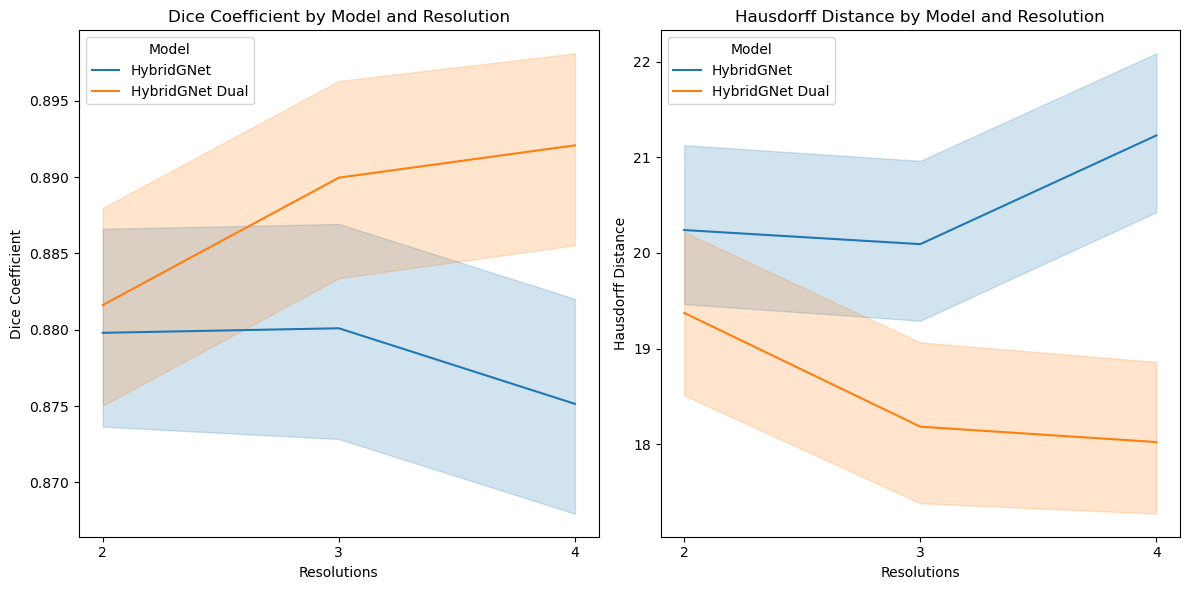

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.lineplot(data=df, x='Resolutions', y='dc', hue="Model", markers=True, dashes=False)
plt.title('Dice Coefficient by Model and Resolution')
plt.xticks(ticks=df['Resolutions'].unique(), labels=df['Resolutions'].unique().astype(int))
plt.ylabel('Dice Coefficient')

plt.subplot(1, 2, 2)
sns.lineplot(data=df, x='Resolutions', y='hd', hue="Model", markers=True, dashes=False)
plt.title('Hausdorff Distance by Model and Resolution')
plt.xticks(ticks=df['Resolutions'].unique(), labels=df['Resolutions'].unique().astype(int))
plt.ylabel('Hausdorff Distance')

plt.tight_layout()
plt.savefig("CAMUS_Resolutions.png")
plt.show()


In [7]:
big_comparison = ["../Results/CAMUS/CAMUS_s/results.csv",
                  "../Results/CAMUS/CAMUS_dual/results.csv",
                  "../Results/CAMUS/NonNaive/CAMUS_NN/results.csv",
                  "../Results/CAMUS/NonNaive/CAMUS_NN_dual/results.csv",
                  "../Results/CAMUS/nnUNet/results.csv"]

model = ["HybridGNet Independent", "HybridGNet Dual Independent", "HybridGNet Unified", "HybridGNet Dual Unified", "nnUNet"]
adjancency = ["Naive", "Naive", "NonNaive", "NonNaive", "-"]

df = pd.DataFrame()
for i, path in enumerate(big_comparison):
    df_temp = pd.read_csv(path)
    df_temp["Model"] = model[i]
    df_temp["Adjacency"] = adjancency[i]
    # replace values in organ column, Myo with Epi
    df_temp['organ'] = df_temp['organ'].replace({'LV Myo': 'LV Epi'})
    print(df_temp.columns)
    df = pd.concat([df,df_temp])


df['patient'] = df['image'].str.split('/').str[0]
df['chamber'] = df['image'].str.split('/').str[1]
df['slice'] = df['image'].str.split('/').str[2]
df['slice'] = df['slice'].str.split('.').str[0]
df['slice'] = df['slice'].astype(int)

df = df.drop(columns=['image'])

# there are many slices for each patient, we need first and last slice per patient
# first slice is end-diastole, last slice is end-systole
# we need dc, hd and assd for these slices
df_first = df[df['slice']==0]
# we do not know the last slice, so we need to find it
df_last = df.groupby('patient').slice.max().reset_index()
df_last = pd.merge(df_last,df,how='left',on=['patient','slice'])
df_last = df_last.drop(columns=['slice'])

# add a column time, and set it to ED or ES
df_first['time'] = 'ED'
df_last['time'] = 'ES'

# merge first and last slice
df = pd.concat([df_first,df_last])
df.drop(columns=['slice'],inplace=True)
df.sort_values(by=['patient','time'],inplace=True)
df.reset_index(drop=True,inplace=True)

Index(['image', 'organ', 'dc', 'hd', 'assd', 'Model', 'Adjacency'], dtype='object')
Index(['image', 'organ', 'dc', 'hd', 'assd', 'Model', 'Adjacency'], dtype='object')
Index(['image', 'organ', 'dc', 'hd', 'assd', 'Model', 'Adjacency'], dtype='object')
Index(['image', 'organ', 'dc', 'hd', 'assd', 'Model', 'Adjacency'], dtype='object')
Index(['image', 'organ', 'dc', 'hd', 'assd', 'Model', 'Adjacency'], dtype='object')


/tmp/ipykernel_1383076/1491547235.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_first['time'] = 'ED'


In [10]:
# Your original code that creates the 'results' table
def format_mean_std(group):
    return f"{group.mean():.3f} ± {group.std():.3f}"

results = df.groupby(['organ', 'Model']).agg({
    'dc': format_mean_std,
    'hd': format_mean_std,
    'assd': format_mean_std
})
results.columns = ['DSC', 'HD', 'ASSD']

# Reshape: Organs as columns, Models as rows
reshaped = results.unstack(level=0)  # Move 'organ' from index to columns

# Reorder columns to group metrics by organ
organs = ['LV Endo', 'LV Epi', 'LA']  # Adjust order as needed
metrics = ['DSC', 'HD', 'ASSD']

# Create new column order
new_columns = []
for organ in organs:
    for metric in metrics:
        new_columns.append((metric, organ))

# Reorder and display
reshaped_ordered = reshaped[new_columns]

print("=== Reshaped Table: Organs as Columns ===")
display(reshaped_ordered)

# Alternative: Flattened column names for cleaner display
flat_df = reshaped_ordered.copy()
flat_df.columns = [f"{organ} - {metric.replace(' Score', '').replace(' Distance', '')}" 
                   for metric, organ in flat_df.columns]

print("\n=== Cleaner Version with Flattened Column Names ===")
display(flat_df)

=== Reshaped Table: Organs as Columns ===


,DSC,HD,ASSD,DSC,HD,ASSD,DSC,HD,ASSD
organ,LV Endo,LV Endo,LV Endo,LV Epi,LV Epi,LV Epi,LA,LA,LA
Model,,,,,,,,,
HybridGNet Dual Independent,0.929 ± 0.039,16.665 ± 7.997,5.452 ± 2.764,0.850 ± 0.065,21.279 ± 8.182,5.951 ± 2.213,0.889 ± 0.074,17.939 ± 11.155,6.192 ± 4.065
HybridGNet Dual Unified,0.930 ± 0.035,17.296 ± 7.777,5.382 ± 2.453,0.855 ± 0.061,20.182 ± 8.487,5.645 ± 2.184,0.886 ± 0.085,18.234 ± 11.393,6.223 ± 4.133
HybridGNet Independent,0.925 ± 0.042,17.285 ± 7.151,5.819 ± 3.021,0.840 ± 0.076,22.181 ± 8.755,6.405 ± 2.557,0.884 ± 0.083,19.105 ± 11.609,6.563 ± 4.837
HybridGNet Unified,0.926 ± 0.038,18.678 ± 8.240,5.699 ± 2.625,0.850 ± 0.058,21.713 ± 9.529,5.896 ± 2.262,0.875 ± 0.094,18.984 ± 10.305,6.836 ± 4.638
nnUNet,0.940 ± 0.027,13.686 ± 5.890,4.575 ± 1.807,0.873 ± 0.048,17.203 ± 6.698,4.889 ± 1.740,0.900 ± 0.076,16.782 ± 12.305,5.491 ± 4.048



=== Cleaner Version with Flattened Column Names ===


,LV Endo - DSC,LV Endo - HD,LV Endo - ASSD,LV Epi - DSC,LV Epi - HD,LV Epi - ASSD,LA - DSC,LA - HD,LA - ASSD
Model,,,,,,,,,
HybridGNet Dual Independent,0.929 ± 0.039,16.665 ± 7.997,5.452 ± 2.764,0.850 ± 0.065,21.279 ± 8.182,5.951 ± 2.213,0.889 ± 0.074,17.939 ± 11.155,6.192 ± 4.065
HybridGNet Dual Unified,0.930 ± 0.035,17.296 ± 7.777,5.382 ± 2.453,0.855 ± 0.061,20.182 ± 8.487,5.645 ± 2.184,0.886 ± 0.085,18.234 ± 11.393,6.223 ± 4.133
HybridGNet Independent,0.925 ± 0.042,17.285 ± 7.151,5.819 ± 3.021,0.840 ± 0.076,22.181 ± 8.755,6.405 ± 2.557,0.884 ± 0.083,19.105 ± 11.609,6.563 ± 4.837
HybridGNet Unified,0.926 ± 0.038,18.678 ± 8.240,5.699 ± 2.625,0.850 ± 0.058,21.713 ± 9.529,5.896 ± 2.262,0.875 ± 0.094,18.984 ± 10.305,6.836 ± 4.638
nnUNet,0.940 ± 0.027,13.686 ± 5.890,4.575 ± 1.807,0.873 ± 0.048,17.203 ± 6.698,4.889 ± 1.740,0.900 ± 0.076,16.782 ± 12.305,5.491 ± 4.048


In [6]:
models = df['Model'].unique()

for i in range(0, (len(models))):
    for j in range(i + 1, len(models)):
        res1 = models[i]
        res2 = models[j]

        data1 = df[df['Model'] == res1]['dc']
        data2 = df[df['Model'] == res2]['dc']

        stat, p_value = wilcoxon(data1, data2)
        # i need to say which is better 
        if p_value < 0.05:
            if np.mean(data1) > np.mean(data2):
                print(f"{res1} is better than {res2} with p-value: {p_value}")
            else:
                print(f"{res2} is better than {res1} with p-value: {p_value}")
        else:
            print(f"No significant difference between {res1} and {res2} with p-value: {p_value}")

HybridGNet Dual Naive is better than HybridGNet Naive with p-value: 6.031767641296492e-05
No significant difference between HybridGNet Naive and HybridGNet Non Naive with p-value: 0.5656152047476654
HybridGNet Dual Non Naive is better than HybridGNet Naive with p-value: 5.984949727513318e-07
nnUNet is better than HybridGNet Naive with p-value: 2.9318704205287336e-25
HybridGNet Dual Naive is better than HybridGNet Non Naive with p-value: 0.0002330044042771937
No significant difference between HybridGNet Dual Naive and HybridGNet Dual Non Naive with p-value: 0.4609592153109032
nnUNet is better than HybridGNet Dual Naive with p-value: 5.689083711298898e-17
HybridGNet Dual Non Naive is better than HybridGNet Non Naive with p-value: 2.8291531005284504e-07
nnUNet is better than HybridGNet Non Naive with p-value: 1.3323521409235375e-27
nnUNet is better than HybridGNet Dual Non Naive with p-value: 4.189362148277753e-16
